# SQLite gaming revenue analysis

This notebook **reads** `data/gaming.sqlite` and walks through the retained official gaming data.
It does **not** download, parse, or write to the database.

- `gaming_results` holds operator or statewide observations we kept from collectors.
- `source_coverage` describes what each collector found (ok, partial, blocked, etc.).
- One logical period can have multiple `source_sha256` values when a regulator revises a report.
- Revenue definitions differ by state: GGR, AGR, taxable revenue, and net proceeds are **not** interchangeable.

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import project_root
from variant_gaming.consolidate import (
    build_operator_revenue,
    build_state_period_revenue,
    dedupe_latest_observation,
)
from variant_gaming.storage import default_db_path

ROOT = project_root()
database_path = default_db_path(ROOT)
connection = sqlite3.connect(
    f"file:{database_path.as_posix()}?mode=ro",
    uri=True,
)
database_path, database_path.stat().st_size


(WindowsPath('C:/Users/Sean/VscProjects/researchOS/data/gaming.sqlite'),
 13893632)

In [2]:
coverage = pd.read_sql_query("SELECT * FROM source_coverage", connection)
results = pd.read_sql_query("SELECT * FROM gaming_results", connection)

print(f"gaming_results rows: {len(results):,}")
print(f"states with rows: {results['state_code'].nunique()}")

rows_by_state_vertical = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(rows_by_state_vertical)

period_span = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .agg(earliest_period=("period_start", "min"), latest_period=("period_end", "max"))
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(period_span)

non_ok_coverage = coverage.loc[coverage["status"] != "ok", ["state_code", "vertical", "status", "reason"]].copy()
display(non_ok_coverage.sort_values(["status", "state_code"]))

gaming_results rows: 18,394
states with rows: 19


,state_code,vertical,row_count
0,CT,online_casino,223
1,CT,online_sports_betting,174
2,DC,online_sports_betting,62
3,DE,online_casino,612
4,IA,online_sports_betting,1669
5,IL,online_sports_betting,891
6,IN,online_sports_betting,1025
7,LA,online_sports_betting,55
8,MA,online_sports_betting,291
9,MD,online_sports_betting,351


,state_code,vertical,earliest_period,latest_period
0,CT,online_casino,2021-10-01,2026-07-31
1,CT,online_sports_betting,2021-10-01,2026-07-31
2,DC,online_sports_betting,2024-07-01,2026-07-31
3,DE,online_casino,2013-11-01,2026-07-31
4,IA,online_sports_betting,2019-08-01,2026-07-31
5,IL,online_sports_betting,2020-03-01,2026-06-30
6,IN,online_sports_betting,2019-10-01,2026-07-31
7,LA,online_sports_betting,2021-07-01,2026-07-31
8,MA,online_sports_betting,2023-03-01,2026-07-31
9,MD,online_sports_betting,2024-08-01,2026-07-31


,state_code,vertical,status,reason
33,OR,online_sports_betting,annual_only,Official public reporting is mainly annual/sum...
16,AZ,online_sports_betting,blocked,Official reports landing blocked for automated...
34,DE,online_sports_betting,blocked,Official tables split casino sportsbooks vs Sp...
19,KY,online_sports_betting,blocked,Current sports wagering market report is Table...
27,WY,online_sports_betting,blocked_or_unavailable_export,Combined wagering activity landing returned no...
29,AR,online_sports_betting,combined_only,Official public landing does not expose an iso...
30,NV,online_sports_betting,combined_only,Official GRI monthly PDFs provide sports-pool ...
21,ME,online_casino,legal_not_reporting,"I-Gaming authorized in law, but no official op..."
32,MT,location_based_mobile_sports_betting,location_based_mobile,Montana sports wagers are tied to sales-agent ...
28,FL,online_sports_betting,not_publicly_available,No official monthly online sportsbook series o...


## Build current analytical views

We reuse `variant_gaming.consolidate` instead of inventing new rules in the notebook.

1. **Amendments must be deduplicated.** Official PDFs and Excel files get revised. `gaming_results` keeps every hash, but charts should use one latest observation per business key (`dedupe_latest_observation`).
2. **Do not blindly sum revenue across bases.** GGR, AGR, taxable revenue, and net proceeds measure different legal concepts.
3. **Keep `revenue_basis` on every chart and table.** The label prevents treating Massachusetts taxable gaming revenue as if it were another state's GGR.

In [3]:
latest_results = dedupe_latest_observation(results)
state_period = build_state_period_revenue(results)
operator_revenue = build_operator_revenue(results)

print(f"raw rows: {len(results):,} | after latest-observation dedupe: {len(latest_results):,}")
print(f"state-period rows: {len(state_period):,} | operator rows: {len(operator_revenue):,}")
display(state_period["revenue_basis"].value_counts(dropna=False).rename("periods"))

raw rows: 18,394 | after latest-observation dedupe: 18,392
state-period rows: 2,270 | operator rows: 16,567


revenue_basis
GGR                1386
taxable_revenue     475
net_proceeds        292
AGR                  76
NaN                  41
Name: periods, dtype: int64

In [4]:
latest_idx = state_period.groupby(["state_code", "vertical"])["period_start"].idxmax()
latest_overview = (
    state_period.loc[latest_idx]
    .loc[:, [
        "state_code",
        "vertical",
        "period_start",
        "handle",
        "revenue",
        "revenue_basis",
        "operator_count",
        "aggregation_source",
    ]]
    .rename(columns={"period_start": "latest_month", "revenue": "reported_revenue"})
    .sort_values(["state_code", "vertical"])
    .reset_index(drop=True)
)
latest_overview

,state_code,vertical,latest_month,handle,reported_revenue,revenue_basis,operator_count,aggregation_source
0,CT,online_casino,2026-07-01,1.865517e+09,5.556381e+07,GGR,4,operator_sum
1,CT,online_sports_betting,2026-07-01,1.756544e+08,1.266224e+07,GGR,3,operator_sum
2,DC,online_sports_betting,2026-07-01,2.412010e+07,2.314579e+06,GGR,2,operator_sum
3,DE,online_casino,2026-07-01,3.584446e+08,1.343825e+07,net_proceeds,3,official_statewide_total
4,IA,online_sports_betting,2026-07-01,1.731755e+08,1.678639e+07,net_proceeds,19,official_statewide_total
5,IL,online_sports_betting,2026-06-01,1.121596e+09,8.941282e+07,AGR,16,official_statewide_total
6,IN,online_sports_betting,2026-07-01,3.776077e+08,4.080943e+07,GGR,11,official_statewide_total
7,LA,online_sports_betting,2026-07-01,2.692667e+08,3.331711e+07,net_proceeds,0,official_statewide_total
8,MA,online_sports_betting,2026-07-01,5.871019e+08,6.510199e+07,taxable_revenue,7,operator_sum
9,MD,online_sports_betting,2026-07-01,4.891599e+08,4.195000e+07,taxable_revenue,15,official_statewide_total


## Massachusetts online sportsbook walkthrough

Massachusetts reports **Taxable Gaming Revenue**, not GGR. Charts and tables below keep that label.

In [5]:
ma_operators = operator_revenue.loc[
    (operator_revenue["state_code"] == "MA")
    & (operator_revenue["vertical"] == "online_sports_betting")
].copy()

ma_monthly = (
    ma_operators.groupby("period_start", as_index=False)
    .agg(
        handle=("handle", "sum"),
        taxable_revenue=("taxable_revenue", "sum"),
        tax=("tax", "sum"),
        operator_count=("operator", "nunique"),
    )
)
ma_monthly["period_start"] = pd.to_datetime(ma_monthly["period_start"])
ma_monthly["taxable_revenue_hold_pct"] = (
    100.0 * ma_monthly["taxable_revenue"] / ma_monthly["handle"]
)
ma_monthly = ma_monthly.sort_values("period_start").reset_index(drop=True)

display(ma_monthly.head(3))
display(ma_monthly.tail(3))


,period_start,handle,taxable_revenue,tax,operator_count,taxable_revenue_hold_pct
0,2023-03-01,5.481025e+08,45605606.68,9121121.34,6,8.320635
1,2023-04-01,5.662369e+08,58548295.26,11709653.81,6,10.339895
2,2023-05-01,4.435597e+08,59410840.40,11882168.06,8,13.394102


,period_start,handle,taxable_revenue,tax,operator_count,taxable_revenue_hold_pct
38,2026-05-01,6.249865e+08,70070108.76,14014021.76,7,11.211460
39,2026-06-01,6.089041e+08,53623096.13,10724619.23,7,8.806493
40,2026-07-01,5.871019e+08,65101989.55,13020397.81,7,11.088704


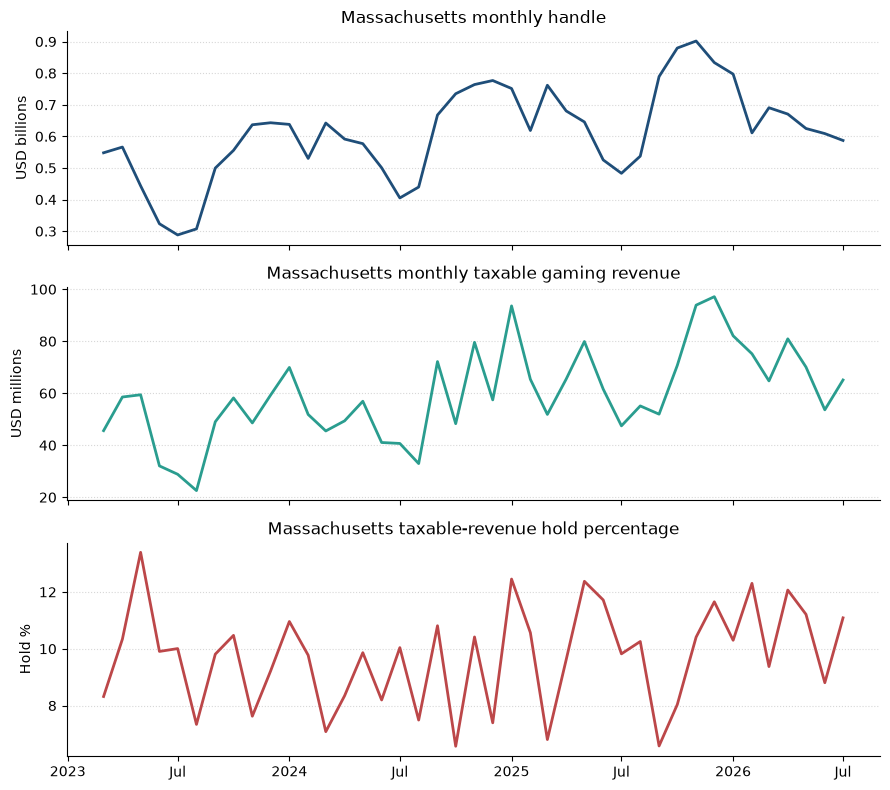

In [6]:
COLOR_HANDLE = "#1f4e79"
COLOR_TAXABLE = "#2a9d8f"
COLOR_HOLD = "#bc4749"

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(ma_monthly["period_start"], ma_monthly["handle"] / 1e9, color=COLOR_HANDLE, linewidth=2)
axes[0].set_ylabel("USD billions")
axes[0].set_title("Massachusetts monthly handle")
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(
    ma_monthly["period_start"],
    ma_monthly["taxable_revenue"] / 1e6,
    color=COLOR_TAXABLE,
    linewidth=2,
)
axes[1].set_ylabel("USD millions")
axes[1].set_title("Massachusetts monthly taxable gaming revenue")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[2].plot(
    ma_monthly["period_start"],
    ma_monthly["taxable_revenue_hold_pct"],
    color=COLOR_HOLD,
    linewidth=2,
)
axes[2].set_ylabel("Hold %")
axes[2].set_title("Massachusetts taxable-revenue hold percentage")
axes[2].grid(axis="y", linestyle=":", alpha=0.5)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

locator = mdates.MonthLocator(bymonth=(1, 7))
formatter = mdates.ConciseDateFormatter(locator)
for axis in axes:
    axis.xaxis.set_major_locator(locator)
    axis.xaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()


Latest Massachusetts reporting month: July 2026


,operator,handle,taxable_revenue,handle_share_pct,taxable_revenue_share_pct
0,DraftKings,2.811763e+08,32324402.68,47.892254,49.651943
1,FanDuel,1.505948e+08,16801318.96,25.650547,25.807689
2,Fanatics,5.968206e+07,6453759.09,10.165537,9.913305
3,BetMGM,5.279115e+07,6386566.27,8.991820,9.810094
4,theScore Bet,2.198188e+07,1622011.39,3.744134,2.491493
5,Caesars Sportsbook,1.760358e+07,1129965.58,2.998386,1.735685
6,Bally Bet,3.272046e+06,383965.58,0.557322,0.589791


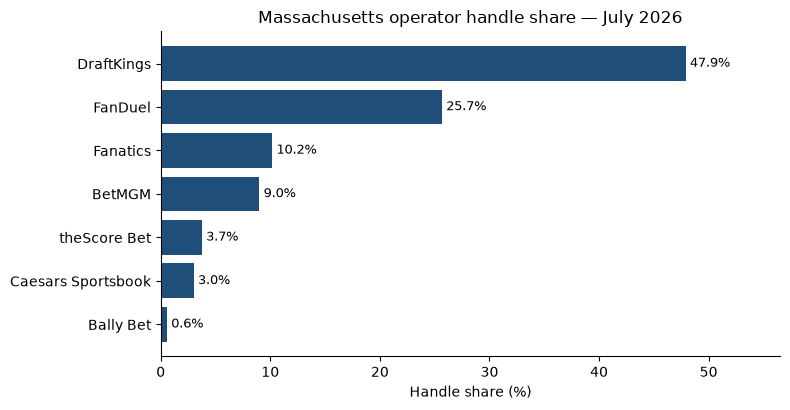

In [7]:
latest_ma_month = ma_monthly["period_start"].iloc[-1]
latest_ma_label = latest_ma_month.strftime("%B %Y")
print(f"Latest Massachusetts reporting month: {latest_ma_label}")

ma_latest_ops = ma_operators.loc[
    pd.to_datetime(ma_operators["period_start"]) == latest_ma_month
].copy()
handle_total = ma_latest_ops["handle"].sum()
taxable_total = ma_latest_ops["taxable_revenue"].sum()

ma_shares = ma_latest_ops.loc[:, ["operator", "handle", "taxable_revenue"]].copy()
ma_shares["handle_share_pct"] = 100.0 * ma_shares["handle"] / handle_total
ma_shares["taxable_revenue_share_pct"] = 100.0 * ma_shares["taxable_revenue"] / taxable_total
ma_shares = ma_shares.sort_values("handle_share_pct", ascending=False).reset_index(drop=True)
display(ma_shares)

plot_frame = ma_shares.sort_values("handle_share_pct")
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(plot_frame["operator"], plot_frame["handle_share_pct"], color=COLOR_HANDLE)
ax.set_xlabel("Handle share (%)")
ax.set_title(f"Massachusetts operator handle share — {latest_ma_label}")
ax.set_xlim(0, plot_frame["handle_share_pct"].max() * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for bar, value in zip(bars, plot_frame["handle_share_pct"]):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
plt.show()


## Comparable multi-state online sportsbooks (monthly GGR only)

This section compares states that report **monthly online sportsbook GGR with usable handle**.

Inclusion rules (all required):

- `vertical == "online_sports_betting"`
- `frequency == "monthly"`
- `revenue_basis == "GGR"`
- positive, non-null handle
- non-null revenue

Massachusetts taxable gaming revenue, Illinois AGR, Iowa/Louisiana net proceeds, and other bases are excluded here on purpose.


Data-quality warning: 98 NJ online sportsbook row(s) are invalid for this GGR comparison (98 with missing or non-positive handle) and are excluded.
Latest max-coverage month: July 2026 (7 comparable GGR states)
Same-month comparison: July 2026 vs July 2025


,state,handle,GGR,hold_pct,handle_yoy_pct,ggr_yoy_pct,hold_change_bps
0,OH,$0.62B,$66.5M,10.78%,+18.2%,+12.9%,-50 bps
1,NC,$0.57B,$63.2M,11.16%,+52.9%,+178.7%,+504 bps
2,IN,$0.38B,$40.8M,10.81%,+34.8%,+21.2%,-121 bps
3,MI,$0.36B,$43.4M,12.21%,+25.6%,+27.2%,+15 bps
4,CT,$0.18B,$12.7M,7.21%,+48.9%,-0.2%,-355 bps
5,NH,$0.06B,$7.3M,11.32%,+46.2%,+49.8%,+28 bps
6,DC,$0.02B,$2.3M,9.60%,+26.2%,+48.0%,+141 bps


Trailing 12 months ending July 2026 vs preceding 12 months (Aug 2025-Jul 2026 vs Aug 2024-Jul 2025)


,state,t12_handle,t12_ggr,t12_hold_pct,prior_t12_hold_pct,handle_growth_pct,ggr_growth_pct,hold_change_bps
0,OH,$10.20B,$1074.9M,10.54%,9.60%,+7.0%,+17.5%,+94 bps
1,NC,$7.82B,$835.3M,10.68%,9.42%,+17.3%,+33.0%,+126 bps
2,IN,$5.73B,$571.7M,9.97%,9.43%,+6.1%,+12.2%,+54 bps
3,MI,$5.61B,$713.7M,12.71%,9.85%,+4.2%,+34.5%,+287 bps
4,CT,$2.45B,$203.3M,8.31%,8.84%,+12.3%,+5.5%,-54 bps
5,NH,$0.88B,$102.1M,11.66%,11.32%,+18.5%,+22.1%,+34 bps
6,DC,$0.34B,$33.4M,9.78%,10.27%,+45.6%,+38.6%,-49 bps


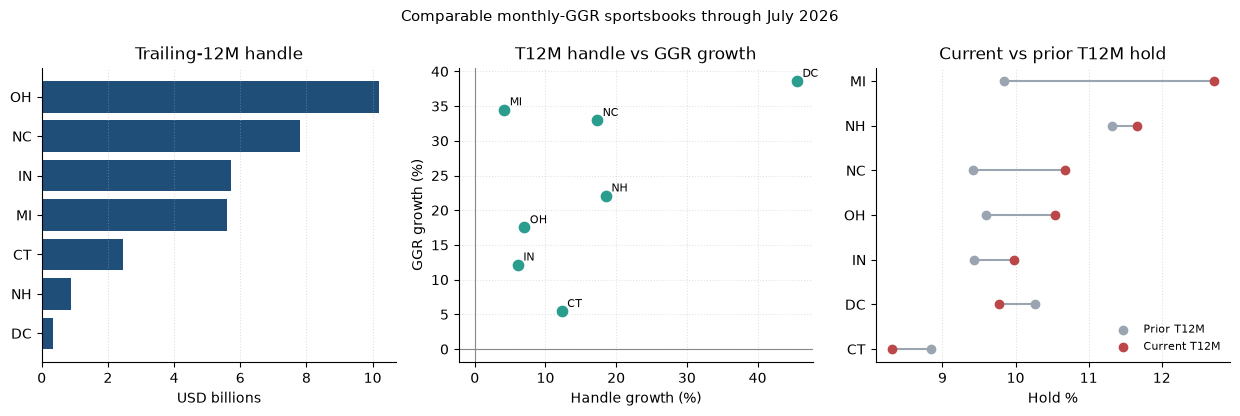

Computed observations (descriptive, not causal):
- Largest comparable market by trailing-12M handle: OH ($10.20B).
- Fastest trailing-12M handle growth: DC (+45.6%). Note: this growth comes from a much smaller handle base.
- GGR growth most exceeds handle growth: MI (GGR +34.5% vs handle +4.2%; hold change +287 bps).
- Handle growth most exceeds GGR growth: DC (handle +45.6% vs GGR +38.6%; hold change -49 bps).


In [8]:
comparable = state_period.loc[
    (state_period["vertical"] == "online_sports_betting")
    & (state_period["frequency"] == "monthly")
    & (state_period["revenue_basis"] == "GGR")
].copy()
comparable["period_start"] = pd.to_datetime(comparable["period_start"])
comparable["handle"] = pd.to_numeric(comparable["handle"], errors="coerce")
comparable["revenue"] = pd.to_numeric(comparable["revenue"], errors="coerce")

valid_ggr = comparable.loc[
    comparable["handle"].notna()
    & (comparable["handle"] > 0)
    & comparable["revenue"].notna()
].copy()

# Warn only when NJ sportsbook rows fail the same validity rules used above.
nj_candidates = comparable.loc[comparable["state_code"] == "NJ"].copy()
nj_invalid = nj_candidates.loc[
    ~(
        nj_candidates["handle"].notna()
        & (nj_candidates["handle"] > 0)
        & nj_candidates["revenue"].notna()
    )
].copy()
if not nj_invalid.empty:
    missing_or_nonpositive_handle = int(
        (~nj_invalid["handle"].notna() | ~(nj_invalid["handle"] > 0)).sum()
    )
    missing_revenue = int((~nj_invalid["revenue"].notna()).sum())
    reasons = []
    if missing_or_nonpositive_handle:
        reasons.append(
            f"{missing_or_nonpositive_handle} with missing or non-positive handle"
        )
    if missing_revenue:
        reasons.append(f"{missing_revenue} with missing revenue")
    print(
        "Data-quality warning: "
        f"{len(nj_invalid)} NJ online sportsbook row(s) are invalid for this GGR comparison "
        f"({'; '.join(reasons)}) and are excluded."
    )

coverage_by_month = (
    valid_ggr.groupby("period_start")["state_code"].nunique().sort_index()
)
max_coverage = int(coverage_by_month.max())
compare_month = coverage_by_month[coverage_by_month == max_coverage].index.max()
prior_month = compare_month - pd.DateOffset(years=1)
compare_label = compare_month.strftime("%B %Y")
prior_label = prior_month.strftime("%B %Y")
print(
    f"Latest max-coverage month: {compare_label} "
    f"({max_coverage} comparable GGR states)"
)

current = valid_ggr.loc[valid_ggr["period_start"] == compare_month].set_index("state_code")
prior = valid_ggr.loc[valid_ggr["period_start"] == prior_month].set_index("state_code")
states = sorted(set(current.index).intersection(prior.index))

yoys = []
for state in states:
    handle_now = float(current.loc[state, "handle"])
    ggr_now = float(current.loc[state, "revenue"])
    handle_prev = float(prior.loc[state, "handle"])
    ggr_prev = float(prior.loc[state, "revenue"])
    hold_now = 100.0 * ggr_now / handle_now
    hold_prev = 100.0 * ggr_prev / handle_prev
    yoys.append(
        {
            "state": state,
            "handle": handle_now,
            "GGR": ggr_now,
            "hold_pct": hold_now,
            "handle_yoy_pct": 100.0 * (handle_now / handle_prev - 1.0),
            "ggr_yoy_pct": 100.0 * (ggr_now / ggr_prev - 1.0),
            "hold_change_bps": (hold_now - hold_prev) * 100.0,
        }
    )
monthly_yoy = pd.DataFrame(yoys).sort_values("handle", ascending=False).reset_index(drop=True)

def trailing_windows(end_month: pd.Timestamp):
    current_start = end_month - pd.DateOffset(months=11)
    prior_end = end_month - pd.DateOffset(years=1)
    prior_start = prior_end - pd.DateOffset(months=11)
    return current_start, end_month, prior_start, prior_end

t12_start, t12_end, p12_start, p12_end = trailing_windows(compare_month)
expected_current_months = pd.date_range(t12_start, t12_end, freq="MS")
expected_prior_months = pd.date_range(p12_start, p12_end, freq="MS")


def exact_month_window(group: pd.DataFrame, expected_months: pd.DatetimeIndex) -> pd.DataFrame | None:
    """Require every expected month exactly once; fail closed on gaps or duplicates."""
    window = group.loc[group["period_start"].isin(expected_months)].copy()
    month_counts = window["period_start"].value_counts()
    if set(window["period_start"]) != set(expected_months):
        return None
    if not (month_counts == 1).all():
        return None
    if len(window) != len(expected_months):
        return None
    return window.sort_values("period_start")


t12_rows = []
for state, group in valid_ggr.groupby("state_code"):
    current_window = exact_month_window(group, expected_current_months)
    prior_window = exact_month_window(group, expected_prior_months)
    if current_window is None or prior_window is None:
        continue
    handle_now = float(current_window["handle"].sum())
    ggr_now = float(current_window["revenue"].sum())
    handle_prev = float(prior_window["handle"].sum())
    ggr_prev = float(prior_window["revenue"].sum())
    hold_now = 100.0 * ggr_now / handle_now
    hold_prev = 100.0 * ggr_prev / handle_prev
    t12_rows.append(
        {
            "state": state,
            "t12_handle": handle_now,
            "t12_ggr": ggr_now,
            "t12_hold_pct": hold_now,
            "prior_t12_hold_pct": hold_prev,
            "handle_growth_pct": 100.0 * (handle_now / handle_prev - 1.0),
            "ggr_growth_pct": 100.0 * (ggr_now / ggr_prev - 1.0),
            "hold_change_bps": (hold_now - hold_prev) * 100.0,
        }
    )
trailing_12 = pd.DataFrame(t12_rows).sort_values("t12_handle", ascending=False).reset_index(drop=True)

print(f"Same-month comparison: {compare_label} vs {prior_label}")
display(
    monthly_yoy.assign(
        handle=lambda d: d["handle"].map(lambda x: f"${x/1e9:.2f}B"),
        GGR=lambda d: d["GGR"].map(lambda x: f"${x/1e6:.1f}M"),
        hold_pct=lambda d: d["hold_pct"].map(lambda x: f"{x:.2f}%"),
        handle_yoy_pct=lambda d: d["handle_yoy_pct"].map(lambda x: f"{x:+.1f}%"),
        ggr_yoy_pct=lambda d: d["ggr_yoy_pct"].map(lambda x: f"{x:+.1f}%"),
        hold_change_bps=lambda d: d["hold_change_bps"].map(lambda x: f"{x:+.0f} bps"),
    )
)
print(
    f"Trailing 12 months ending {compare_label} vs preceding 12 months "
    f"({t12_start.strftime('%b %Y')}-{t12_end.strftime('%b %Y')} vs "
    f"{p12_start.strftime('%b %Y')}-{p12_end.strftime('%b %Y')})"
)
display(
    trailing_12.assign(
        t12_handle=lambda d: d["t12_handle"].map(lambda x: f"${x/1e9:.2f}B"),
        t12_ggr=lambda d: d["t12_ggr"].map(lambda x: f"${x/1e6:.1f}M"),
        t12_hold_pct=lambda d: d["t12_hold_pct"].map(lambda x: f"{x:.2f}%"),
        prior_t12_hold_pct=lambda d: d["prior_t12_hold_pct"].map(lambda x: f"{x:.2f}%"),
        handle_growth_pct=lambda d: d["handle_growth_pct"].map(lambda x: f"{x:+.1f}%"),
        ggr_growth_pct=lambda d: d["ggr_growth_pct"].map(lambda x: f"{x:+.1f}%"),
        hold_change_bps=lambda d: d["hold_change_bps"].map(lambda x: f"{x:+.0f} bps"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))

t12_plot = trailing_12.sort_values("t12_handle")
axes[0].barh(t12_plot["state"], t12_plot["t12_handle"] / 1e9, color=COLOR_HANDLE)
axes[0].set_xlabel("USD billions")
axes[0].set_title("Trailing-12M handle")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="x", linestyle=":", alpha=0.4)

axes[1].axhline(0, color="#888888", linewidth=0.8)
axes[1].axvline(0, color="#888888", linewidth=0.8)
axes[1].scatter(
    trailing_12["handle_growth_pct"],
    trailing_12["ggr_growth_pct"],
    s=55,
    color=COLOR_TAXABLE,
    zorder=3,
)
for _, row in trailing_12.iterrows():
    axes[1].annotate(
        row["state"],
        (row["handle_growth_pct"], row["ggr_growth_pct"]),
        fontsize=8,
        xytext=(4, 3),
        textcoords="offset points",
    )
axes[1].set_xlabel("Handle growth (%)")
axes[1].set_ylabel("GGR growth (%)")
axes[1].set_title("T12M handle vs GGR growth")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(linestyle=":", alpha=0.35)

hold_plot = trailing_12.sort_values("t12_hold_pct")
y = range(len(hold_plot))
axes[2].hlines(y, hold_plot["prior_t12_hold_pct"], hold_plot["t12_hold_pct"], color="#9aa5b1", linewidth=1.5)
axes[2].scatter(hold_plot["prior_t12_hold_pct"], y, color="#9aa5b1", label="Prior T12M", zorder=3)
axes[2].scatter(hold_plot["t12_hold_pct"], y, color=COLOR_HOLD, label="Current T12M", zorder=3)
axes[2].set_yticks(list(y))
axes[2].set_yticklabels(hold_plot["state"])
axes[2].set_xlabel("Hold %")
axes[2].set_title("Current vs prior T12M hold")
axes[2].legend(frameon=False, fontsize=8, loc="lower right")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].grid(axis="x", linestyle=":", alpha=0.4)

fig.suptitle(f"Comparable monthly-GGR sportsbooks through {compare_label}", fontsize=11)
fig.tight_layout()
plt.show()

largest = trailing_12.iloc[0]
fastest = trailing_12.sort_values("handle_growth_pct", ascending=False).iloc[0]
median_handle = float(trailing_12["t12_handle"].median())
ggr_over_handle = (
    trailing_12.assign(gap=lambda d: d["ggr_growth_pct"] - d["handle_growth_pct"])
    .sort_values("gap", ascending=False)
    .iloc[0]
)
handle_over_ggr = (
    trailing_12.assign(gap=lambda d: d["handle_growth_pct"] - d["ggr_growth_pct"])
    .sort_values("gap", ascending=False)
    .iloc[0]
)

print("Computed observations (descriptive, not causal):")
print(
    f"- Largest comparable market by trailing-12M handle: {largest['state']} "
    f"(${largest['t12_handle']/1e9:.2f}B)."
)
small_base_note = (
    " Note: this growth comes from a much smaller handle base."
    if fastest["t12_handle"] < 0.5 * median_handle
    else ""
)
print(
    f"- Fastest trailing-12M handle growth: {fastest['state']} "
    f"({fastest['handle_growth_pct']:+.1f}%).{small_base_note}"
)
print(
    f"- GGR growth most exceeds handle growth: {ggr_over_handle['state']} "
    f"(GGR {ggr_over_handle['ggr_growth_pct']:+.1f}% vs handle {ggr_over_handle['handle_growth_pct']:+.1f}%; "
    f"hold change {ggr_over_handle['hold_change_bps']:+.0f} bps)."
)
print(
    f"- Handle growth most exceeds GGR growth: {handle_over_ggr['state']} "
    f"(handle {handle_over_ggr['handle_growth_pct']:+.1f}% vs GGR {handle_over_ggr['ggr_growth_pct']:+.1f}%; "
    f"hold change {handle_over_ggr['hold_change_bps']:+.0f} bps)."
)

connection.close()


## Basic observations and limits

The cells above inventory SQLite coverage, rebuild latest analytical views with the existing consolidate helpers, walk through Massachusetts taxable-revenue trends, and compare only monthly GGR sportsbook states with usable handle.

**Revenue-basis limitation.** GGR, AGR, taxable revenue, and net proceeds are different metrics. Massachusetts is analyzed separately because it reports taxable gaming revenue, not GGR.

**Reporting-lag limitation.** "Latest month" means the latest *available* official month with usable data, not the current calendar month.

**Data-quality limitation.** NJ online sportsbook rows currently lack usable handle and show implausible revenue magnitudes, so they are excluded from the comparable GGR section rather than repaired here.

**What to do next.** Choose the next analytical question (seasonality, operator continuity, or another PDF state) before promoting more plotting helpers into modules.
